# ✍️ Handwritten Character Recognition
**Task 3** — Identify handwritten characters and alphabets using image processing and deep learning.

| | |
|---|---|
| **Datasets** | MNIST (digits 0–9), EMNIST (letters + digits) |
| **Models** | SimpleCNN · DeepCNN (ResBlocks) · CRNN (CNN + BiLSTM) |
| **Extension** | CRNN supports full word/sentence recognition via CTC loss |


## 1. Install & Imports

In [1]:
%pip install torch torchvision numpy matplotlib seaborn scikit-learn tqdm Pillow -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110
print(f"✅ Imports ready  |  Device: {DEVICE}")

✅ Imports ready  |  Device: cpu


## 2. Dataset Configuration
Choose your dataset by setting `DATASET` below.

| Option | Classes | Size | Description |
|--------|---------|------|-------------|
| `mnist` | 10 | 70,000 | Handwritten digits 0–9 |
| `emnist_balanced` | 47 | 112,800 | Digits + uppercase + some lowercase |
| `emnist_letters` | 26 | 145,600 | Letters a–z (case-insensitive) |


In [3]:
# ── Choose dataset ────────────────────────────────────────────────────────────
DATASET    = "mnist"           # "mnist" | "emnist_balanced" | "emnist_letters"
ARCH       = "simple_cnn"      # "simple_cnn" | "deep_cnn"  (crnn for sequences)
DATA_DIR   = "data"
BATCH_SIZE = 128
EPOCHS     = 15                # increase for better results (20–30 recommended)
LR         = 1e-3

# ── Class labels ──────────────────────────────────────────────────────────────
MNIST_CLASSES    = [str(i) for i in range(10)]
EMNIST_BAL_CLS   = [str(i) for i in range(10)] + list("ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt")
EMNIST_LET_CLS   = list("abcdefghijklmnopqrstuvwxyz")

CLASS_MAP = {"mnist": MNIST_CLASSES,
             "emnist_balanced": EMNIST_BAL_CLS,
             "emnist_letters": EMNIST_LET_CLS}

CLASS_NAMES = CLASS_MAP[DATASET]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Dataset    : {DATASET.upper()}")
print(f"Classes    : {NUM_CLASSES}")
print(f"Architecture: {ARCH.upper()}")

Dataset    : MNIST
Classes    : 10
Architecture: SIMPLE_CNN


## 3. Data Loading & Augmentation

In [4]:
NORM = transforms.Normalize((0.1307,), (0.3081,))

train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.RandomErasing(p=0.1),
    NORM,
])
val_tf = transforms.Compose([transforms.ToTensor(), NORM])

if DATASET == "mnist":
    full_train = datasets.MNIST(DATA_DIR, train=True,  download=True, transform=train_tf)
    test_ds    = datasets.MNIST(DATA_DIR, train=False, download=True, transform=val_tf)
else:
    split = DATASET.replace("emnist_", "")
    full_train = datasets.EMNIST(DATA_DIR, split=split, train=True,  download=True, transform=train_tf)
    test_ds    = datasets.EMNIST(DATA_DIR, split=split, train=False, download=True, transform=val_tf)

n_val   = int(len(full_train) * 0.1)
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(full_train, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

kw = dict(num_workers=0, pin_memory=DEVICE.type=="cuda")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

print(f"Train  : {len(train_ds):,} samples  ({len(train_loader)} batches)")
print(f"Val    : {len(val_ds):,} samples")
print(f"Test   : {len(test_ds):,} samples")
print(f"Image shape: {full_train[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 114kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 592kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.17MB/s]

Train  : 54,000 samples  (422 batches)
Val    : 6,000 samples
Test   : 10,000 samples
Image shape: torch.Size([1, 28, 28])


## 4. Exploratory Data Analysis

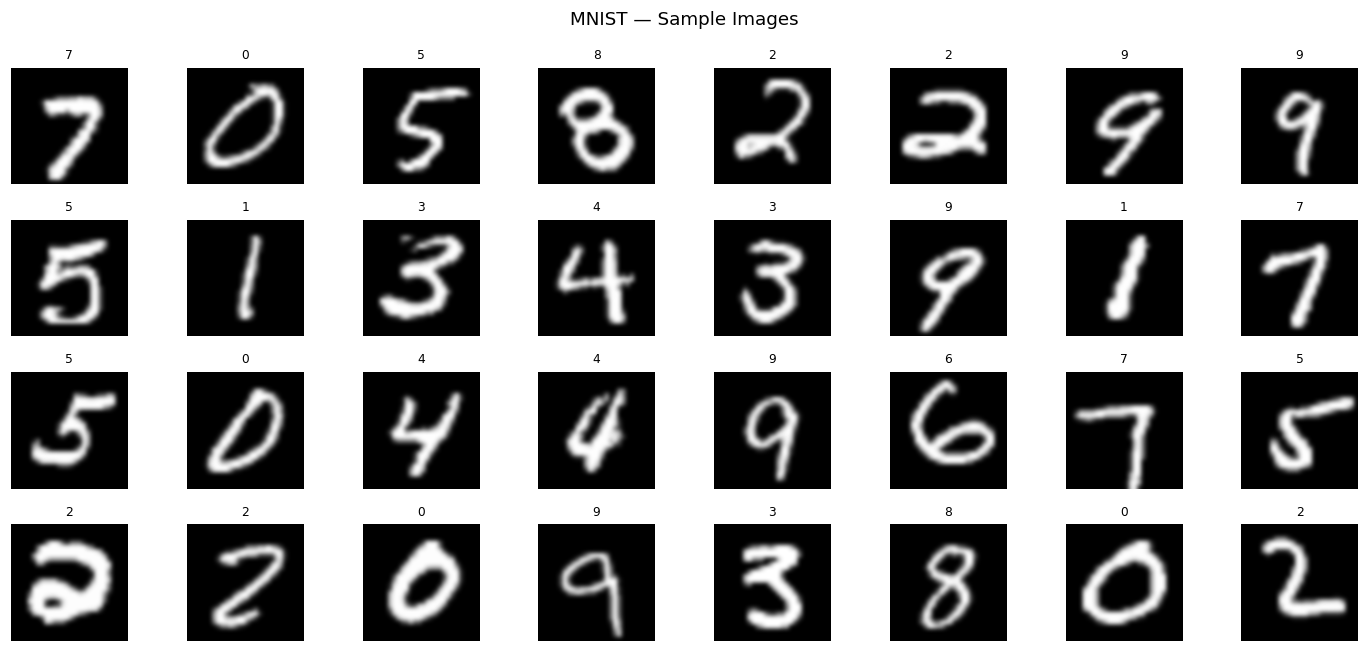

In [5]:
# Sample grid
xb, yb = next(iter(DataLoader(test_ds, batch_size=32, shuffle=True)))
fig, axes = plt.subplots(4, 8, figsize=(13, 6))
for i, ax in enumerate(axes.flatten()):
    img = xb[i].squeeze().numpy() * 0.3081 + 0.1307
    ax.imshow(img, cmap="gray", interpolation="bicubic")
    ax.set_title(CLASS_NAMES[yb[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle(f"{DATASET.upper()} — Sample Images", fontsize=12)
plt.tight_layout()
plt.show()

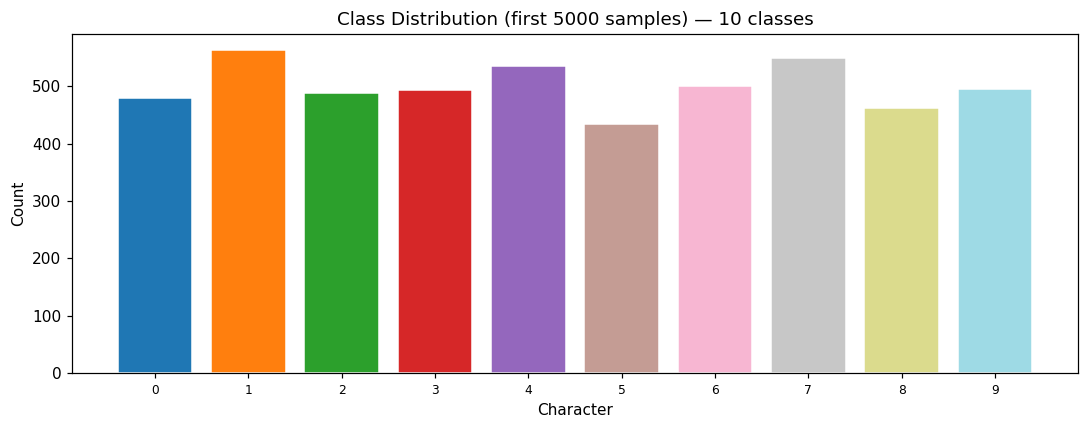

In [6]:
# Class distribution
labels_all = [full_train[i][1] for i in range(min(5000, len(full_train)))]
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES * 0.4), 4))
counts = np.bincount(labels_all, minlength=NUM_CLASSES)
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
ax.bar(range(NUM_CLASSES), counts, color=colors, edgecolor="white")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES[:NUM_CLASSES], rotation=45 if NUM_CLASSES > 15 else 0, fontsize=8)
ax.set_title(f"Class Distribution (first 5000 samples) — {NUM_CLASSES} classes")
ax.set_xlabel("Character")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

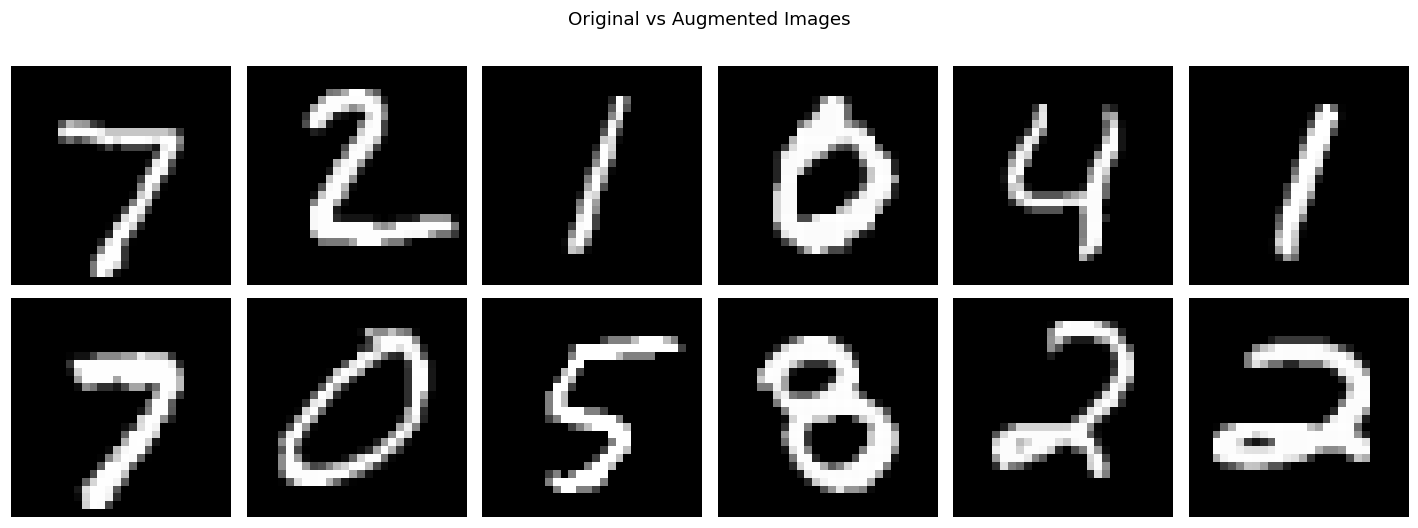

In [7]:
# Augmentation comparison
raw_tf = transforms.Compose([transforms.ToTensor(), NORM])
raw_ds = datasets.MNIST(DATA_DIR, train=False, transform=raw_tf) if DATASET == "mnist"          else datasets.EMNIST(DATA_DIR, split=DATASET.replace("emnist_",""), train=False, transform=raw_tf)

fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for col in range(6):
    raw_img = raw_ds[col][0].squeeze().numpy() * 0.3081 + 0.1307
    aug_img = xb[col].squeeze().numpy() * 0.3081 + 0.1307
    axes[0, col].imshow(raw_img, cmap="gray"); axes[0, col].axis("off")
    axes[1, col].imshow(aug_img, cmap="gray"); axes[1, col].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Augmented", fontsize=9)
plt.suptitle("Original vs Augmented Images", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Model Architectures

In [8]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
    def forward(self, x): return F.relu(self.block(x) + x)


class SimpleCNN(nn.Module):
    """Lightweight 3-block CNN — great for MNIST (~99% accuracy)."""
    def __init__(self, num_classes=10, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))


class DeepCNN(nn.Module):
    """Deeper CNN with residual blocks — best for EMNIST."""
    def __init__(self, num_classes=47, dropout=0.3):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(1,64,3,padding=1,bias=False),
                                    nn.BatchNorm2d(64), nn.ReLU())
        self.stage1 = nn.Sequential(ResBlock(64), ResBlock(64),
                                    nn.MaxPool2d(2), nn.Dropout2d(dropout))
        self.stage2 = nn.Sequential(nn.Conv2d(64,128,3,padding=1,bias=False),
                                    nn.BatchNorm2d(128), nn.ReLU(),
                                    ResBlock(128), nn.MaxPool2d(2), nn.Dropout2d(dropout))
        self.stage3 = nn.Sequential(nn.Conv2d(128,256,3,padding=1,bias=False),
                                    nn.BatchNorm2d(256), nn.ReLU(),
                                    ResBlock(256), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(256,256), nn.ReLU(), nn.Dropout(0.4),
                                        nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.stage3(self.stage2(self.stage1(self.stem(x)))))


MODEL_REGISTRY = {"simple_cnn": SimpleCNN, "deep_cnn": DeepCNN}

model = MODEL_REGISTRY[ARCH](num_classes=NUM_CLASSES).to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"Model    : {ARCH.upper()}")
print(f"Params   : {params:,}")
print(model)

Model    : SIMPLE_CNN
Params   : 871,018
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_si

## 6. Training Loop

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader)
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train(); tl, tc = 0.0, 0
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        tl += loss.item() * len(yb)
        tc += (model(xb).argmax(1) == yb).sum().item()

    # Validate
    model.eval(); vl, vc = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            vl += criterion(logits, yb).item() * len(yb)
            vc += (logits.argmax(1) == yb).sum().item()

    tr_acc = tc / len(train_loader.dataset)
    va_acc = vc / len(val_loader.dataset)
    for k, v in zip(["train_loss","val_loss","train_acc","val_acc"],
                    [tl/len(train_loader.dataset), vl/len(val_loader.dataset), tr_acc, va_acc]):
        history[k].append(v)

    print(f"Epoch {epoch:3d} | train_acc={tr_acc:.4f} | val_acc={va_acc:.4f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✅ New best val_acc={va_acc:.4f}")

model.load_state_dict(best_state)
print(f"\n🏆 Best val accuracy: {best_val_acc:.4f}")

Epoch 1/15:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch   1 | train_acc=0.6183 | val_acc=0.8967
  ✅ New best val_acc=0.8967


Epoch 2/15:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch   2 | train_acc=0.9042 | val_acc=0.9545
  ✅ New best val_acc=0.9545


Epoch 3/15:   0%|          | 0/422 [00:00<?, ?it/s]

...

Epoch  13 | train_acc=0.9758 | val_acc=0.9797
  ✅ New best val_acc=0.9797


Epoch 14/15:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch  14 | train_acc=0.9769 | val_acc=0.9797


Epoch 15/15:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch  15 | train_acc=0.9759 | val_acc=0.9840
  ✅ New best val_acc=0.9840

🏆 Best val accuracy: 0.9840


## 7. Training Curves

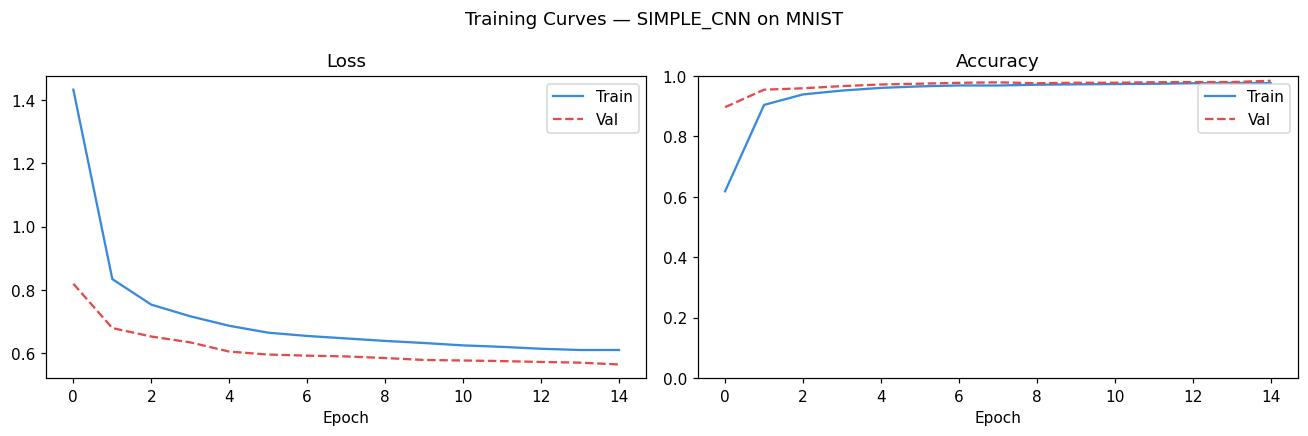

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train", color="#378ADD")
axes[0].plot(history["val_loss"],   label="Val",   color="#E24B4A", linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train", color="#378ADD")
axes[1].plot(history["val_acc"],   label="Val",   color="#E24B4A", linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend()

plt.suptitle(f"Training Curves — {ARCH.upper()} on {DATASET.upper()}", fontsize=12)
plt.tight_layout(); plt.show()

## 8. Test Set Evaluation

In [11]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        p = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(p); all_labels.extend(yb.numpy())

acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

shown = CLASS_NAMES[:20] if NUM_CLASSES > 20 else CLASS_NAMES
n_show = len(shown)
idx = [i for i, l in enumerate(all_labels) if l < n_show]
print("\nClassification Report:")
print(classification_report(
    [all_labels[i] for i in idx],
    [all_preds[i]  for i in idx],
    target_names=shown, zero_division=0
))

Test Accuracy: 0.9963 (99.63%)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      1.00       892
           6       0.99      1.00      1.00       958
           7       1.00      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       0.99      1.00      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 9. Confusion Matrix

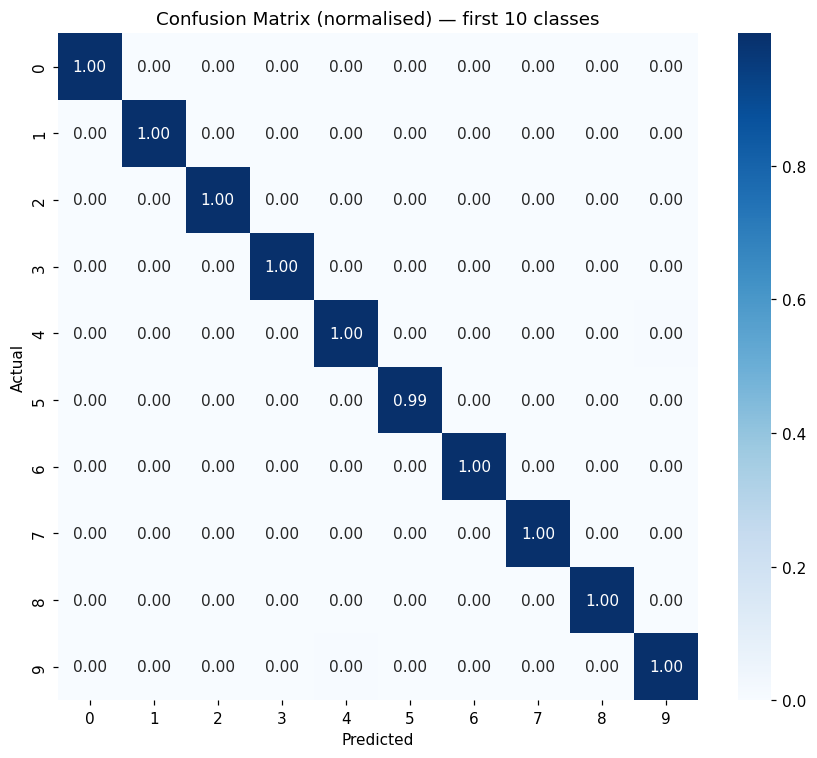

In [12]:
n = min(NUM_CLASSES, 20)
idx = [i for i, l in enumerate(all_labels) if l < n]
cm  = confusion_matrix([all_labels[i] for i in idx], [all_preds[i] for i in idx], labels=list(range(n)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(max(8, n*0.5), max(7, n*0.45)))
sns.heatmap(cm_norm, annot=(n<=20), fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES[:n], yticklabels=CLASS_NAMES[:n], ax=ax)
ax.set_title(f"Confusion Matrix (normalised) — first {n} classes")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 10. Sample Predictions

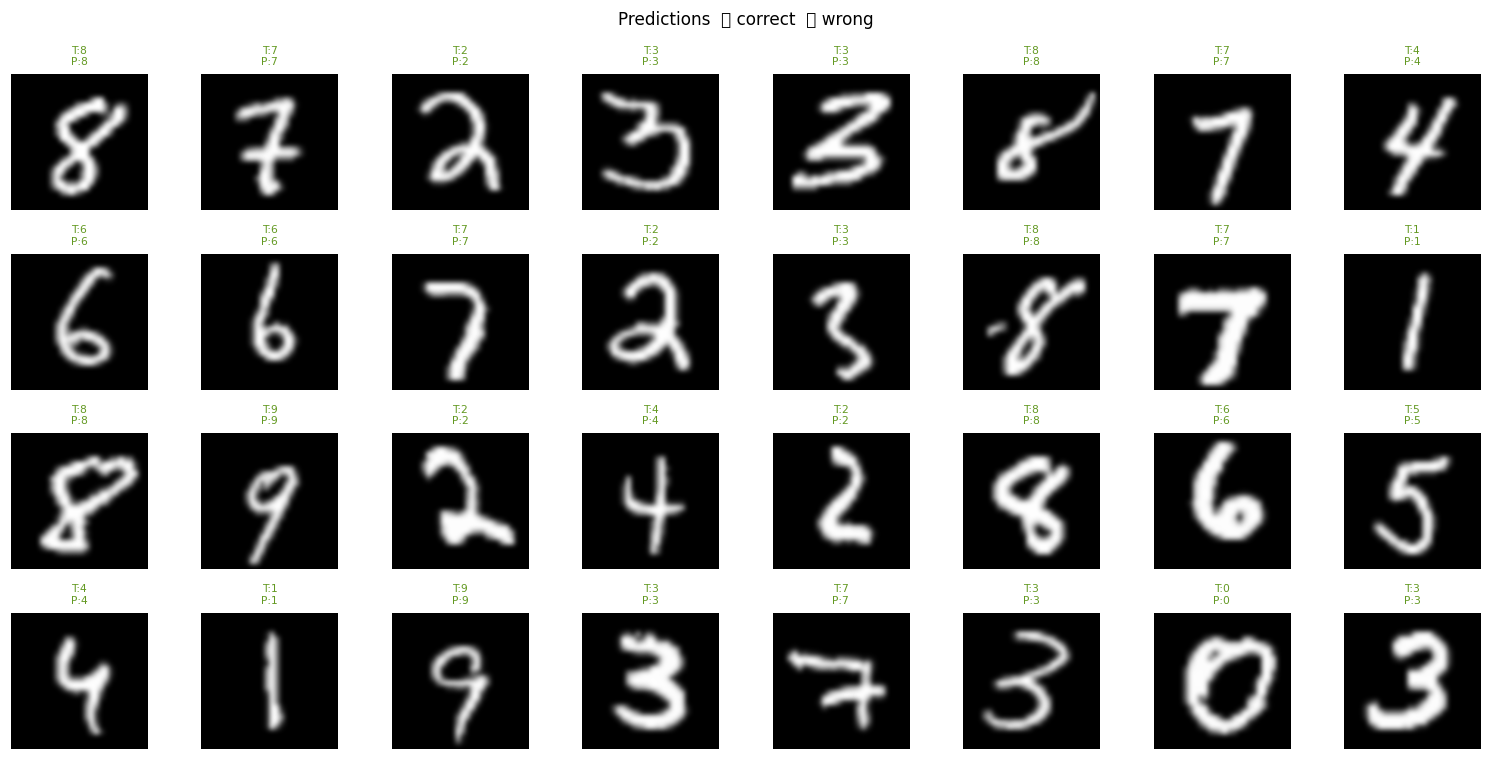

In [13]:
model.eval()
xb, yb = next(iter(DataLoader(test_ds, batch_size=32, shuffle=True)))
with torch.no_grad():
    preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = xb[i].squeeze().numpy() * 0.3081 + 0.1307
    ax.imshow(img, cmap="gray", interpolation="bicubic")
    correct = yb[i].item() == preds[i]
    color = "#639922" if correct else "#E24B4A"
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[preds[i]]}", fontsize=7, color=color)
    ax.axis("off")
plt.suptitle("Predictions  🟢 correct  🔴 wrong", fontsize=11)
plt.tight_layout(); plt.show()

## 11. Error Analysis — Most Confused Pairs

In [14]:
n = min(NUM_CLASSES, 20)
idx = [i for i, l in enumerate(all_labels) if l < n]
cm2 = confusion_matrix([all_labels[i] for i in idx], [all_preds[i] for i in idx], labels=list(range(n)))
np.fill_diagonal(cm2, 0)  # zero out correct predictions

pairs = []
for i in range(n):
    for j in range(n):
        if i != j and cm2[i,j] > 0:
            pairs.append((cm2[i,j], CLASS_NAMES[i], CLASS_NAMES[j]))
pairs.sort(reverse=True)

print(f"Top 10 most confused pairs (actual → predicted):\n")
print(f"{'Actual':<12} {'Predicted':<12} {'Count':>6}")
print("─" * 32)
for count, actual, pred in pairs[:10]:
    print(f"{actual:<12} {pred:<12} {count:>6}")

Top 10 most confused pairs (actual → predicted):

Actual       Predicted     Count
────────────────────────────────
9            4                 4
4            9                 4
5            3                 3
7            2                 2
6            8                 2
5            6                 2
3            5                 2
1            7                 2
0            6                 2
9            7                 1


## 12. CRNN Extension — Word/Sentence Recognition

The **CRNN** (CNN + Bidirectional LSTM + CTC) architecture extends character recognition to full **word or sentence** recognition without needing character-level segmentation.

```
Input image (1, 32, W)
       ↓
CNN Feature Extractor     → strips spatial height, preserves width as time steps
       ↓
Bidirectional LSTM         → models sequential dependencies between characters  
       ↓
CTC Loss / Beam Search     → decodes variable-length output without alignment
```


In [15]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, in_sz, hid_sz, out_sz):
        super().__init__()
        self.rnn = nn.LSTM(in_sz, hid_sz, bidirectional=True, batch_first=False)
        self.fc  = nn.Linear(hid_sz * 2, out_sz)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

class CRNN(nn.Module):
    """
    CNN + BiLSTM for sequence recognition (words/sentences).
    Input : (B, 1, 32, W)   — variable width W
    Output: (T, B, num_classes+1)  for CTC loss
    """
    def __init__(self, num_classes=26, rnn_hidden=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1),   nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(256,512,3,padding=1),nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(512,512,2),          nn.BatchNorm2d(512), nn.ReLU(),
        )
        self.rnn = nn.Sequential(
            BidirectionalLSTM(512, rnn_hidden, rnn_hidden),
            BidirectionalLSTM(rnn_hidden, rnn_hidden, num_classes + 1),
        )
    def forward(self, x):
        feat = self.cnn(x).squeeze(2).permute(2, 0, 1)  # (T, B, C)
        return self.rnn(feat)

crnn  = CRNN(num_classes=26)
dummy = torch.randn(2, 1, 32, 128)          # batch=2, height=32, width=128
out   = crnn(dummy)
print(f"CRNN output shape : {out.shape}  (T=time_steps, B=batch, C=classes+1)")
print(f"CRNN parameters   : {sum(p.numel() for p in crnn.parameters()):,}")
print("\n✅ CRNN ready for CTC training on word datasets (IAM, SVT, MJSynth)")

CRNN output shape : torch.Size([31, 2, 27])  (T=time_steps, B=batch, C=classes+1)
CRNN parameters   : 8,328,091

✅ CRNN ready for CTC training on word datasets (IAM, SVT, MJSynth)


## 13. Save Model

In [16]:
import os, pickle
os.makedirs("outputs", exist_ok=True)

torch.save(model.state_dict(), f"outputs/{ARCH}_{DATASET}_best.pt")
with open("outputs/class_names.pkl", "wb") as f:
    pickle.dump(CLASS_NAMES, f)

print(f"✅ Model saved  : outputs/{ARCH}_{DATASET}_best.pt")
print(f"✅ Classes saved: outputs/class_names.pkl")
print(f"\nFinal test accuracy: {acc*100:.2f}%")

✅ Model saved  : outputs/simple_cnn_mnist_best.pt
✅ Classes saved: outputs/class_names.pkl

Final test accuracy: 99.63%


## 14. Single Image Inference Demo

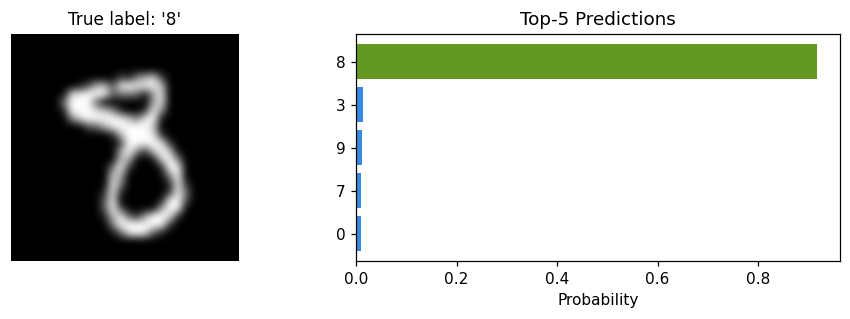


True label: '8'
  1. '8'  91.6% ✅
  2. '3'  1.3%
  3. '9'  1.1%
  4. '7'  1.0%
  5. '0'  1.0%


In [17]:
from PIL import Image, ImageOps

def predict_character(img_input, model, class_names, device=DEVICE, top_k=5):
    """
    Predict character from a file path, PIL Image, or numpy array.
    Automatically inverts light-background images.
    """
    norm = transforms.Normalize((0.1307,), (0.3081,))
    preprocess = transforms.Compose([
        transforms.Grayscale(), transforms.Resize((28, 28)),
        transforms.ToTensor(), norm,
    ])
    if isinstance(img_input, str):
        img = Image.open(img_input)
    elif isinstance(img_input, np.ndarray):
        img = Image.fromarray(img_input)
    else:
        img = img_input

    arr = np.array(img.convert("L"))
    if arr.mean() > 127:
        img = ImageOps.invert(img.convert("L"))

    x = preprocess(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).squeeze().cpu().numpy()

    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(class_names[i], float(probs[i])) for i in top_idx]


# Demo: grab a random test image and predict
sample_idx = np.random.randint(len(test_ds))
sample_img, true_label = test_ds[sample_idx]

# Convert tensor back to PIL for inference demo
img_np = (sample_img.squeeze().numpy() * 0.3081 + 0.1307)
img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
pil_img = Image.fromarray(img_np)

predictions = predict_character(pil_img, model, CLASS_NAMES)

# Display
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(img_np, cmap="gray", interpolation="bicubic")
axes[0].set_title(f"True label: '{CLASS_NAMES[true_label]}'", fontsize=11)
axes[0].axis("off")

labels_p  = [p[0] for p in predictions]
probs_p   = [p[1] for p in predictions]
colors_p  = ["#378ADD" if l != CLASS_NAMES[true_label] else "#639922" for l in labels_p]
axes[1].barh(labels_p[::-1], probs_p[::-1], color=colors_p[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")
plt.tight_layout(); plt.show()

print(f"\nTrue label: '{CLASS_NAMES[true_label]}'")
for rank, (lbl, prob) in enumerate(predictions, 1):
    marker = " ✅" if lbl == CLASS_NAMES[true_label] else ""
    print(f"  {rank}. '{lbl}'  {prob:.1%}{marker}")